In [28]:
#import librarys
#!pip install torch torchvision torchaudio
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [29]:
#1. Load the MNIST data set.

#to transform -changes the 2D images into tensor of 4-dimensions
transform = transforms.ToTensor()

# Download training data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Download test data
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)


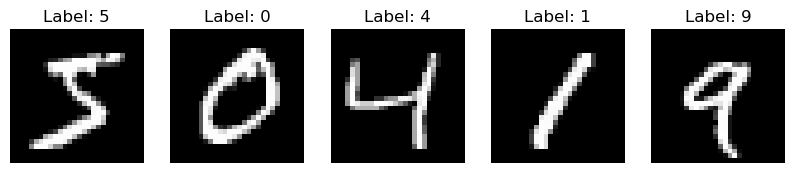

First five labels: [5, 0, 4, 1, 9]


In [30]:
#2. Display the first five images in the training data set. Compare these to the first five training labels.

first_five_images = [train_dataset[i][0] for i in range(5)]
first_five_labels = [train_dataset[i][1] for i in range(5)]

# Plot the first 5 images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(first_five_images[i].squeeze(), cmap='gray')  # .squeeze() removes the channel dimension
    plt.title(f"Label: {first_five_labels[i]}")
    plt.axis('off')
plt.show()

# Print the labels separately for clarity
print("First five labels:", first_five_labels)

In [31]:
#3. Build and train a CNN classifier on the MNIST training set.

#create small batch size for images
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False) #don't shuffle test data

#Define CNN Model - describe convolutional layers
conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)


In [32]:
#grab 1 image to get torch.Size
#for i, (X_Train, y_train) in enumerate(train_dataset):
 #   break

#X_Train.shape

In [33]:
#change into a 4-D batch
#x = X_Train.view(1,1,28,28)

#Perform convolution 1
#x = F.relu(conv1(x)) #rectified linear unit for the activation function
#x.shape

In [34]:
#notes - this is 1 single image, 6 is the filters I asked for, 26x26

In [35]:
#pass through the pooling layer

#x = F.max_pool2d(x, 2, 2) #kernal of 2 and stride of 2
#x.shape

In [36]:
#notes - this is 1 single image, 6 is the filters and now it's 13X13 becuase it's pooled. 

In [37]:
#Perform convolution 2
#x = F.relu(conv2(x)) #rectified linear unit for the activation function
#x.shape

In [38]:
#pass through the pooling layer
#x = F.max_pool2d(x, 2, 2) #kernal of 2 and stride of 2
#x.shape

In [39]:
class ConvolutionalNetwork(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1) #pulled from Define CNN Model
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        #Fully Connected Layers
        self.fc1 = nn.Linear(5*5*16, 120) #torch size - 120 can be changed
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) #10 = classes that we have in the dataset

#forward function 
    def forward(self, X): 
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X,2,2) #Pool 2X2 kernal and stride 2
        #second pass for 2nd convolutional layer
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X,2,2) #Pool 2X2 kernal and stride 2

        #flatten data
        X = X.view(-1, 16*5*5) #negative one so batch size can vary 

        #Fully connected layers
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = (self.fc3(X))
        return F.log_softmax(X, dim=1)
        
        

In [40]:
#create an instance 
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [41]:
#loss function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #smaller the learning rate, the longer it'll take to train 

In [42]:
#create variables to track 

epochs = 5 #want to train 5 times
train_losses = []
test_losses = []
train_correct = []
test_correct = []

In [43]:
#Loop of Epochs
for i in range(epochs):
    trn_corr = 0 
    tst_corr = 0 

    #train
    for b, (X_train, y_train) in enumerate(train_loader):
        b+=1 #start the batch at 1 
        y_pred = model(X_train) #get predicted values from training set(not flattented)
        loss = criterion(y_pred, y_train) #Predictions to correct 

        predicted = torch.max(y_pred.data, 1)[1] #add up the correct predictions 
        batch_corr = (predicted == y_train).sum() #how may are correct in this batch
        trn_corr += batch_corr #keep track in training 

        #update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print out some results
        if b%600 == 0:
            print(f'Epoch: {i} Batch: {b} Loss: {loss.item()}')

    train_losses.append(loss)
    train_correct.append(trn_corr)

Epoch: 0 Batch: 600 Loss: 0.15793977677822113
Epoch: 1 Batch: 600 Loss: 0.20558662712574005
Epoch: 2 Batch: 600 Loss: 0.16004660725593567
Epoch: 3 Batch: 600 Loss: 0.016307437792420387
Epoch: 4 Batch: 600 Loss: 0.009188766591250896


In [44]:
#4. Report the test accuracy of your model.

with torch.no_grad(): #no grradient so weights don't update
    for b, (X_test, y_test) in enumerate(test_loader):
        y_val = model(X_test)
        predicted = torch.max(y_val.data, 1)[1] #adding up correct predictions
        tst_corr += (predicted == y_test).sum() #sums

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

In [45]:
test_load_everything = DataLoader(test_dataset, batch_size=10000, shuffle=False)


In [46]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_everything:
        y_val = model(X_test)
        predicted = torch.max(y_val, 1)[1]
        correct += (predicted == y_test).sum()

In [47]:
accuracy = correct / len(test_dataset) * 100
accuracy

tensor(98.9100)

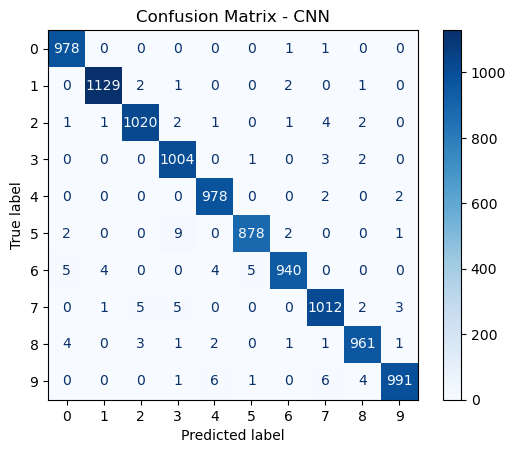

In [48]:
#5. Display a confusion matrix on the test set classifications.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Put the model in evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_load_everything:
        images, labels = images.to(device), labels.to(device)  
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))  # for MNIST 0-9
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - CNN")
plt.show()

#6. Summarize your results.

The accuracy of the model is 98.8% The confusion matrix summarized the performance of the model. It shows that the predications align well with the actual classes in the data. 